In [15]:
import h5py
import numpy as np
import bilby
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from bilby.gw.conversion import (
    chirp_mass_and_mass_ratio_to_component_masses,
    lambda_tilde_delta_lambda_tilde_to_lambda_1_lambda_2,
    component_masses_to_chirp_mass,
    lambda_1_lambda_2_to_lambda_tilde,
)

rng        = np.random.default_rng(seed=42)
N_SAMPLES  = 5000
INPUT_FILE = '/ligo/home/ligo.org/sanika.khadkikar/Projects/stm/post_processing_ns/restructured_networks.h5'

plt.rcParams.update({
    'text.usetex':     True,
    'font.family':     'serif',
    'font.size':       18,
    'axes.labelsize':  18,
    'axes.titlesize':  14,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
    'legend.fontsize': 16,
})

In [16]:
with h5py.File(INPUT_FILE, 'r') as f:
    bns_networks  = list(f['BNS'].keys())
    nsbh_networks = list(f['NSBH'].keys())
    eos_mass      = f['eos_metadata']['mass_msol'][:]
    eos_lambda    = f['eos_metadata']['lambda'][:]
    m_max_tov     = float(f['eos_metadata'].attrs['M_max_TOV'])
    print(f['BNS'][bns_networks[0]].keys())

print(f'BNS:  {len(bns_networks)} networks')
print(f'NSBH: {len(nsbh_networks)} networks')
print(f'M_max_TOV: {m_max_tov:.4f} Msol')

<KeysViewHDF5 ['Lambda1', 'Lambda2', 'LambdaTilde', 'Mc_src', 'condition_number', 'dL', 'dec', 'deltaLambda', 'eta', 'inversion_error', 'm1_src', 'm2_src', 'original_indices', 'phi', 'psi', 'q', 'ra', 'sigma_LambdaTilde', 'sigma_Mc_src', 'sigma_dL', 'sigma_deltaLambda', 'sigma_eta', 'sigma_psi', 'sigma_q', 'sky_area_90', 'snr', 'theta', 'z']>
BNS:  46 networks
NSBH: 46 networks
M_max_TOV: 2.0600 Msol


In [22]:
def draw_samples_for_event(net_grp, idx, n_samples=N_SAMPLES, rng=rng):
    def sample(param):
        return rng.normal(float(net_grp[f'{param}'][idx]), float(net_grp[f'sigma_{param}'][idx]), size=n_samples)

    Mc_src      = sample('Mc_src')
    dL          = sample('dL')
    LambdaTilde = sample('LambdaTilde')
    deltaLambda = sample('deltaLambda')
    psi         = sample('psi')
    q           = np.clip(sample('q'), 1e-6, 1.0)

    m1_src, m2_src = chirp_mass_and_mass_ratio_to_component_masses(Mc_src, q)
    Lambda1, Lambda2 = lambda_tilde_delta_lambda_tilde_to_lambda_1_lambda_2(
        LambdaTilde, deltaLambda, m1_src, m2_src
    )
    Lambda1 = np.clip(Lambda1, 0.0, None)

    return {
        'Mc_src':       Mc_src,
        'q':            q,
        'm1_src':       m1_src,
        'm2_src':       m2_src,
        'dL':           dL,
        'z':            float(net_grp['z'][idx]),
        'LambdaTilde':  LambdaTilde,
        'deltaLambda':  deltaLambda,
        'Lambda1':      Lambda1,
        'Lambda2':      Lambda2,
        'psi':          psi,
        'snr':          float(net_grp['snr'][idx]),
        'sky_area_90':  float(net_grp['sky_area_90'][idx]),
        'm1_src_inj':   float(net_grp['m1_src'][idx]),
        'm2_src_inj':   float(net_grp['m2_src'][idx]),
        'Lambda1_inj':  float(net_grp['Lambda1'][idx]),
        'Lambda2_inj':  float(net_grp['Lambda2'][idx]),
    }

In [23]:
with h5py.File(INPUT_FILE, 'r') as f:
    result = draw_samples_for_event(f['BNS'][bns_networks[0]], 0)

print(f"snr: {result['snr']:.2f}   sky_area_90: {result['sky_area_90']:.2f} deg^2")
print()
for param in ['Mc_src','q','m1_src','m2_src','dL','LambdaTilde','deltaLambda','Lambda1','Lambda2','psi']:
    arr = result[param]
    print(f"{param:20s}: median={np.median(arr):.4f}  std={np.std(arr):.4f}  [{np.percentile(arr,5):.4f}, {np.percentile(arr,95):.4f}]")

print()
print('injection vs sample median')
print(f"m1_src  inj={result['m1_src_inj']:.4f}  median={np.median(result['m1_src']):.4f}")
print(f"m2_src  inj={result['m2_src_inj']:.4f}  median={np.median(result['m2_src']):.4f}")
print(f"Lambda1 inj={result['Lambda1_inj']:.4f}  median={np.median(result['Lambda1']):.4f}")
print(f"Lambda2 inj={result['Lambda2_inj']:.4f}  median={np.median(result['Lambda2']):.4f}")


snr: 17.07   sky_area_90: 122.82 deg^2

Mc_src              : median=1.3453  std=0.0002  [1.3450, 1.3456]
q                   : median=0.8862  std=0.3164  [0.0218, 1.0000]
m1_src              : median=1.6421  std=1105.1282  [1.5451, 13.4036]
m2_src              : median=1.4552  std=0.3921  [0.2926, 1.5456]
dL                  : median=8.0684  std=1.7582  [5.2143, 11.0120]
LambdaTilde         : median=170.8817  std=42.5384  [102.4083, 243.4299]
deltaLambda         : median=26.3360  std=93.8137  [-125.8794, 182.0308]
Lambda1             : median=84.0613  std=191.0987  [0.0000, 401.8173]
Lambda2             : median=288.4631  std=177004177245200896.0000  [-59202.3085, 6724.0197]
psi                 : median=2.0860  std=0.8956  [0.5733, 3.5820]

injection vs sample median
m1_src  inj=1.6542  median=1.6421
m2_src  inj=1.4450  median=1.4552
Lambda1 inj=102.4832  median=84.0613
Lambda2 inj=272.6244  median=288.4631


In [24]:
N_EVENTS = 300   # events sampled per network; each one gets N_SAMPLES draws


def top_networks(f, population, networks, n_top=6):
    """The n_top networks with the most events surviving the inversion error cut."""
    kept = {}
    for n in networks:
        grp = f[population][n]
        kept[n] = int(grp.attrs['kept_events']) if 'kept_events' in grp.attrs else len(grp['z'])
    return sorted(kept, key=lambda n: -kept[n])[:n_top], kept


def mass_lambda_errors(grp, n_events=N_EVENTS, rng=rng):
    """Injected (m, Lambda) with a 1 sigma width from the drawn samples.

    Fisher gives uncertainties, not central values, so every point sits on the
    EOS curve by construction and only the error bars come from the samples.
    """
    n_kept = len(grp['z']) if 'z' in grp else 0
    if n_kept == 0:
        return None

    idx = np.sort(rng.choice(n_kept, size=min(n_events, n_kept), replace=False))
    keys = ['m1_src', 'm2_src', 'Lambda1', 'Lambda2']

    val = {k: grp[k][:][idx] for k in keys}
    err = {k: [] for k in keys}
    for i in idx:
        s = draw_samples_for_event(grp, int(i))
        for k in keys:
            err[k].append(np.std(s[k]))

    return {k: {'val': val[k], 'err': np.asarray(err[k])} for k in keys}


with h5py.File(INPUT_FILE, 'r') as f:
    sorted_bns,  bns_kept  = top_networks(f, 'BNS',  bns_networks)
    sorted_nsbh, nsbh_kept = top_networks(f, 'NSBH', nsbh_networks)

    bns_data  = {n: mass_lambda_errors(f['BNS'][n])  for n in sorted_bns}
    nsbh_data = {n: mass_lambda_errors(f['NSBH'][n]) for n in sorted_nsbh}

print('BNS, most events kept:')
for n in sorted_bns:
    print(f'  {bns_kept[n]:7d}  {n}')
print('NSBH, most events kept:')
for n in sorted_nsbh:
    print(f'  {nsbh_kept[n]:7d}  {n}')


/ligo/home/ligo.org/sanika.khadkikar/.conda/envs/ns_pe/lib/python3.11/site-packages/bilby/gw/conversion.py:1219: RuntimeWarning: invalid value encountered in divide
  (13 * lambda_tilde / 8 * (coefficient_3 - coefficient_4) -
/ligo/home/ligo.org/sanika.khadkikar/.conda/envs/ns_pe/lib/python3.11/site-packages/bilby/gw/conversion.py:1224: RuntimeWarning: divide by zero encountered in divide
  (13 * lambda_tilde / 8 * (coefficient_3 + coefficient_4) -
/ligo/home/ligo.org/sanika.khadkikar/.conda/envs/ns_pe/lib/python3.11/site-packages/numpy/_core/_methods.py:191: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)
/ligo/home/ligo.org/sanika.khadkikar/.conda/envs/ns_pe/lib/python3.11/site-packages/numpy/_core/_methods.py:171: RuntimeWarning: invalid value encountered in reduce
  arrmean = umr_sum(arr, axis, dtype, keepdims=True, where=where)


BNS, most events kept:
    46856  CE40km_1p5MW_Aplus_coat_7.0hz_CE20km_1p5MW_Aplus_coat_7.0hz_ETD_5.0hz
    46574  CE40km_1p5MW_Aplus_coat_5.0hz_CE20km_1p5MW_Aplus_coat_5.0hz_ETD_5.0hz
    45742  CE40km_1p5MW_Aplus_coat_10.0hz_CE20km_1p5MW_Aplus_coat_10.0hz_ETD_5.0hz
    45721  CE40km_1p5MW_Aplus_coat_7.0hz_ET2L_5.0hz
    45420  CE40km_1p5MW_Aplus_coat_5.0hz_ET2L_5.0hz
    44838  CE40km_1p5MW_Aplus_coat_10.0hz_ET2L_5.0hz
NSBH, most events kept:
    30366  CE40km_1p5MW_Aplus_coat_5.0hz_CE20km_1p5MW_Aplus_coat_5.0hz_ETD_5.0hz
    30300  CE40km_1p5MW_Aplus_coat_7.0hz_CE20km_1p5MW_Aplus_coat_7.0hz_ETD_5.0hz
    29940  CE40km_1p5MW_Aplus_coat_10.0hz_CE20km_1p5MW_Aplus_coat_10.0hz_ETD_5.0hz
    29733  CE40km_1p5MW_Aplus_coat_5.0hz_ET2L_5.0hz
    29681  CE40km_1p5MW_Aplus_coat_7.0hz_ET2L_5.0hz
    29353  CE40km_1p5MW_Aplus_coat_10.0hz_ET2L_5.0hz


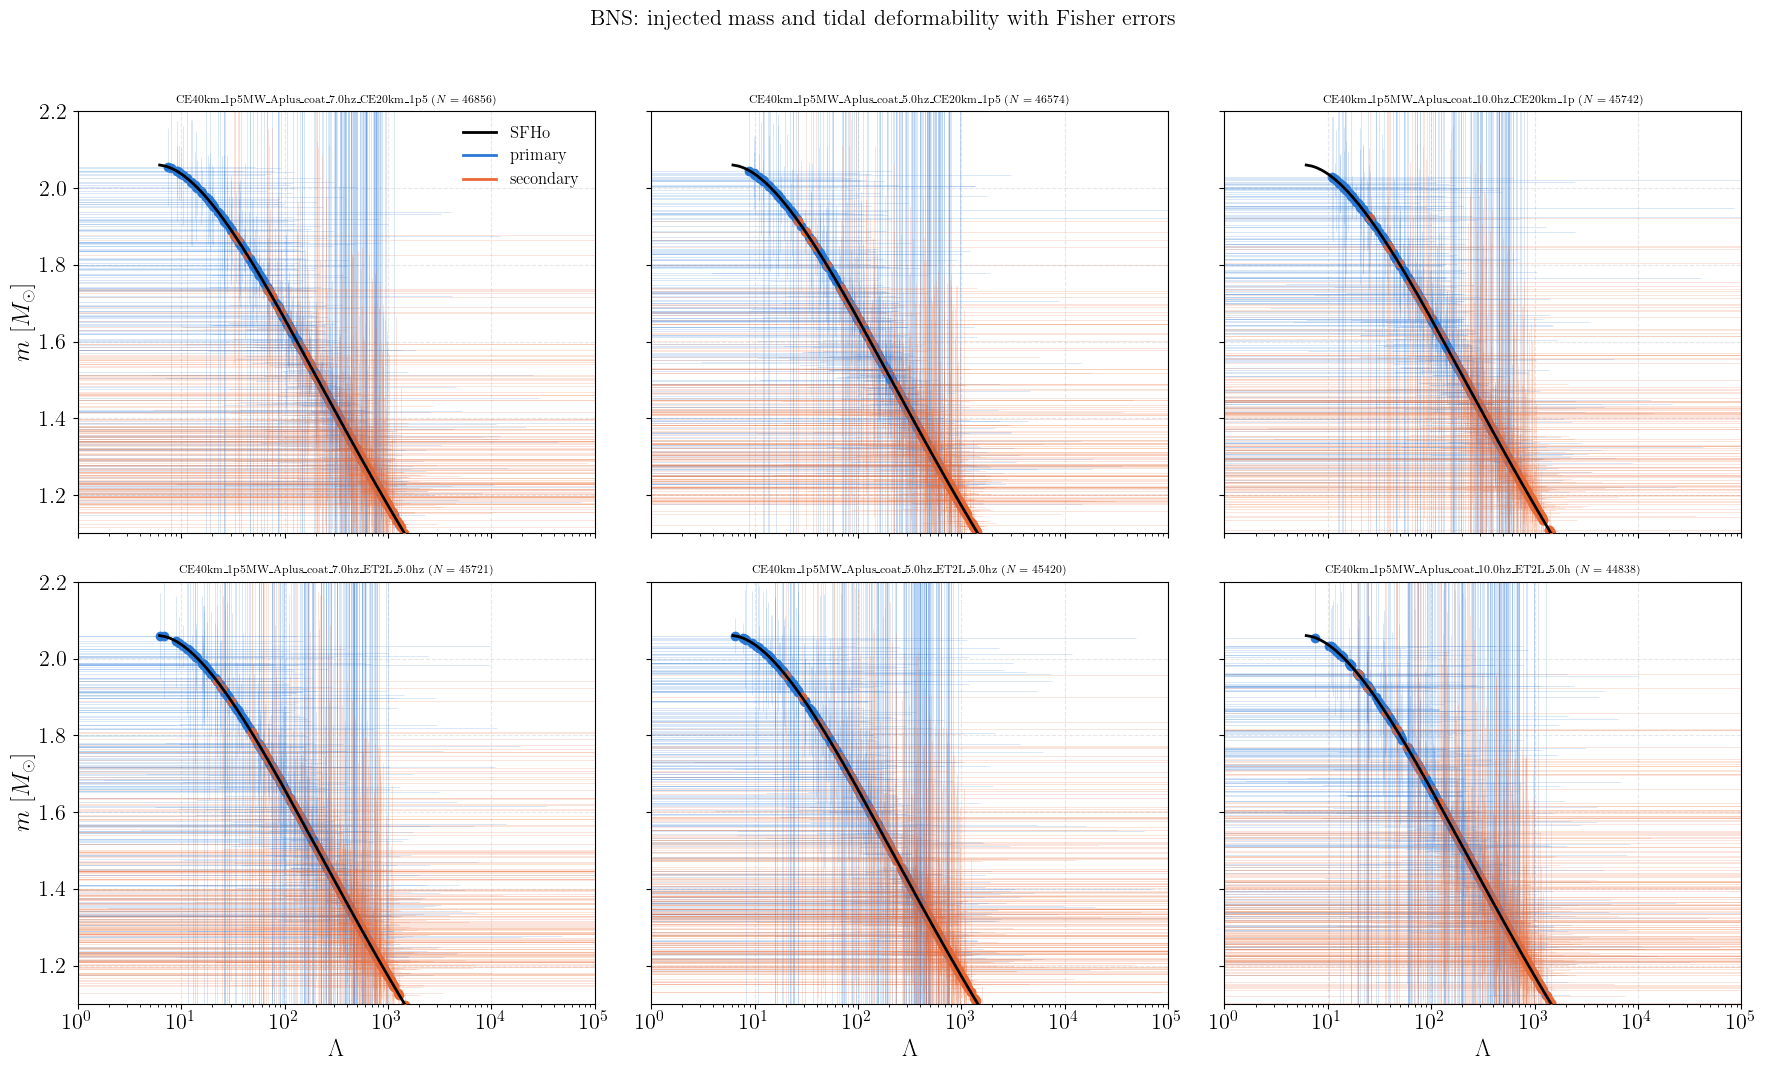

In [25]:
PRIMARY_COLOR   = '#2a78d6'
SECONDARY_COLOR = '#eb6834'


def plot_mass_lambda(sorted_nets, data, kept, components, suptitle, figname='NSBH_m_lambda.pdf'):
    """Mass on y, Lambda on x (log), against the SFHo curve. One panel per network."""
    fig, axes = plt.subplots(2, 3, figsize=(18, 11), sharex=True, sharey=True)

    for ax, net in zip(axes.flatten(), sorted_nets):
        ax.plot(eos_lambda, eos_mass, color='black', lw=2, zorder=5)

        d = data[net]
        if d is not None:
            for m_key, l_key, color, label in components:
                m, lam = d[m_key], d[l_key]
                good = (lam['val'] > 0) & np.isfinite(lam['val']) & np.isfinite(m['val'])
                ax.scatter(lam['val'][good], m['val'][good], color = color)
                ax.errorbar(lam['val'][good], m['val'][good],
                            xerr=lam['err'][good], yerr=m['err'][good],
                            fmt='none', alpha=0.18, lw=0.7, ecolor=color)
                ax.plot(lam['val'][good], m['val'][good], 'o', ms=2.0,
                        color=color, alpha=0.9, mew=0, zorder=4, label=label)
        else:
            ax.text(0.5, 0.5, 'no events', transform=ax.transAxes,
                    ha='center', va='center', color='#52514e')

        ax.set_title(f'{net[:40]} ($N={kept[net]}$)', fontsize=8)
        ax.set_xscale('log')
        ax.set_xlim(1, 1e5)
        ax.set_ylim(1.1, 2.2)
        ax.grid(alpha=0.3, ls='--')
        if ax in axes[:, 0]:
            ax.set_ylabel(r'$m\ [M_\odot]$')
        if ax in axes[1, :]:
            ax.set_xlabel(r'$\Lambda$')

    handles = [plt.Line2D([0], [0], color='black', lw=2, label='SFHo')]
    handles += [plt.Line2D([0], [0], color=c, lw=2, label=lab)
                for _, _, c, lab in components]
    axes[0, 0].legend(handles=handles, frameon=False, fontsize=12)

    fig.suptitle(suptitle, fontsize=16)
    fig.tight_layout(rect=[0, 0, 1, 0.97])
    plt.savefig(figname)
    plt.show()


plot_mass_lambda(
    sorted_bns, bns_data, bns_kept,
    components=[('m1_src', 'Lambda1', PRIMARY_COLOR,   'primary'),
                ('m2_src', 'Lambda2', SECONDARY_COLOR, 'secondary')],
    suptitle='BNS: injected mass and tidal deformability with Fisher errors',
    figname='BNS_m_lambda.pdf'
)

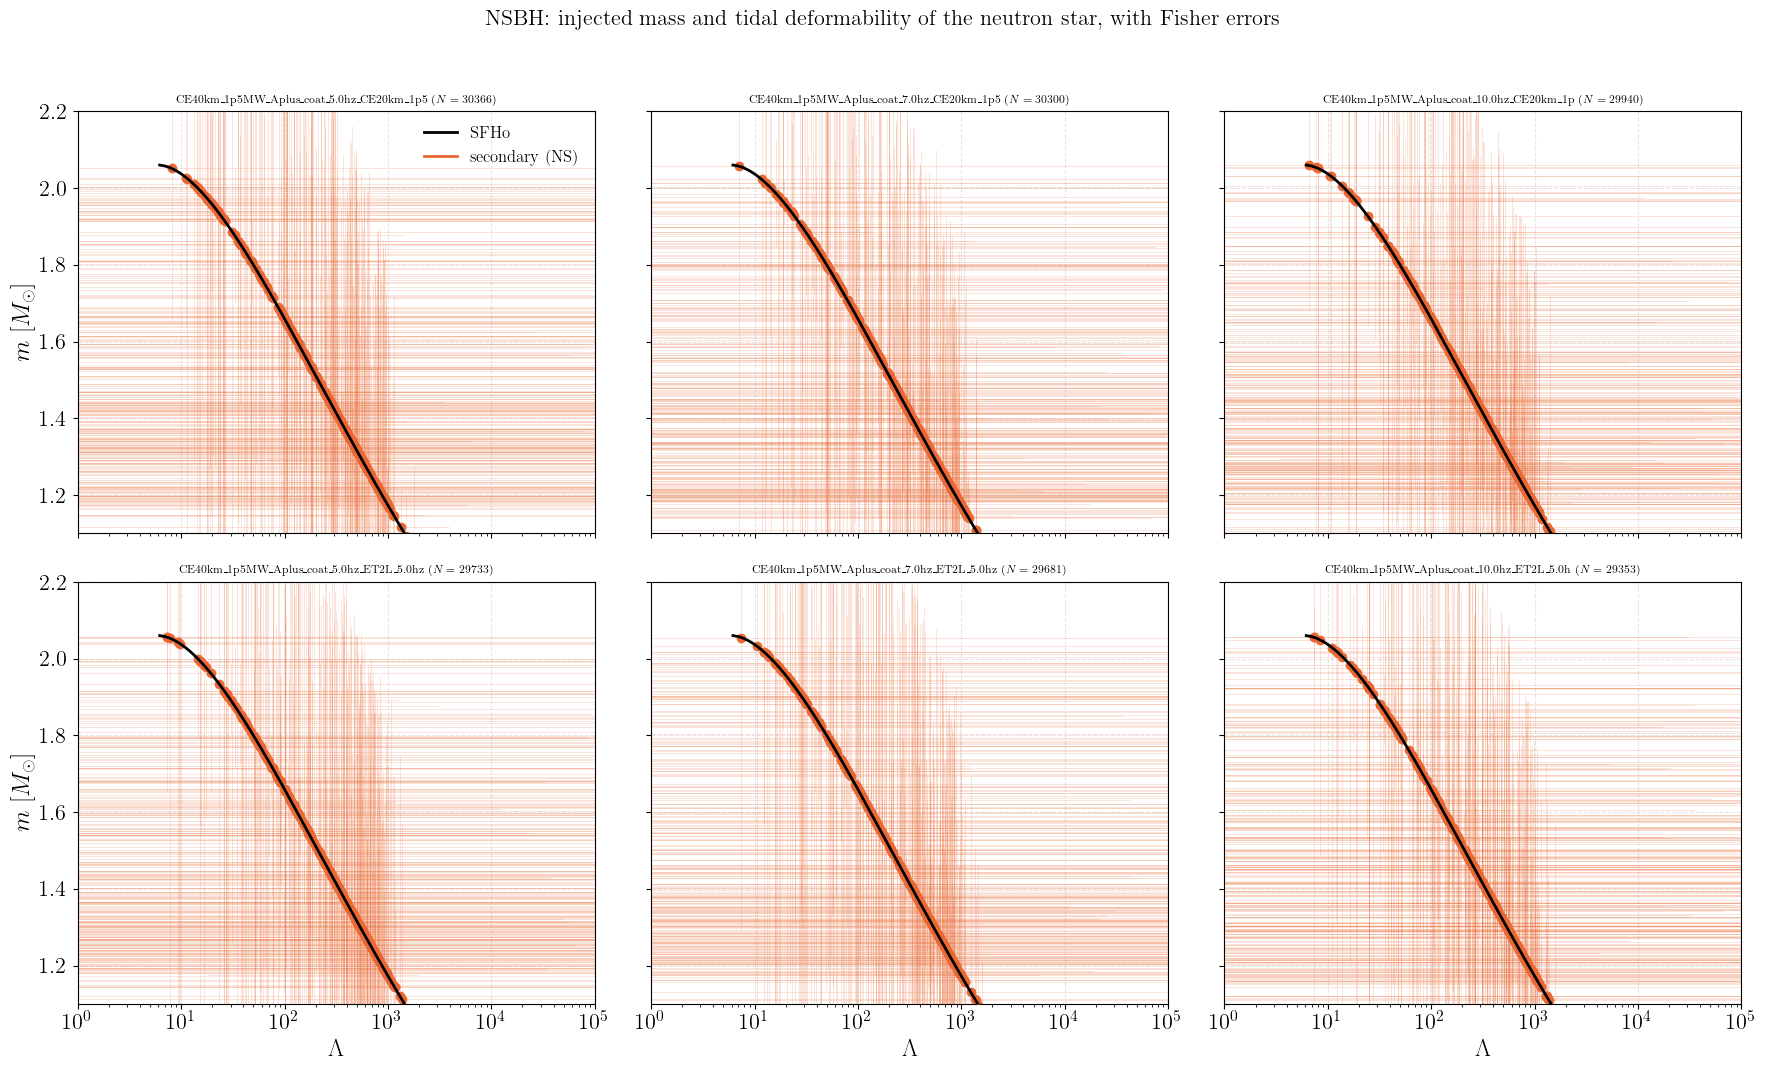

In [26]:
# NSBH primary is a black hole with Lambda1 = 0, so only the secondary is plotted
plot_mass_lambda(
    sorted_nsbh, nsbh_data, nsbh_kept,
    components=[('m2_src', 'Lambda2', SECONDARY_COLOR, 'secondary (NS)')],
    suptitle='NSBH: injected mass and tidal deformability of the neutron star, with Fisher errors',
    figname='NSBH_m_lambda.pdf'
)
